# Assignment 4 — OpenCV Experiments

This notebook demonstrates five core OpenCV experiments as part of the Computer Vision Fellowship Week 1 tasks:

1. Color Space Conversion
2. Image Filtering
3. Edge Detection
4. Contour Detection
5. Shape Detection

Each experiment includes code, output, and an explanation of the underlying concept.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

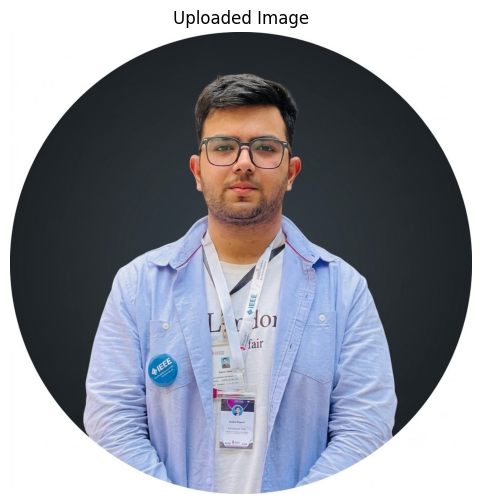

In [ ]:
image = cv2.imread("me ahsan.jpeg")

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Uploaded Image")
plt.axis("off")
plt.show()

---
## Experiment 1: Color Space Conversion



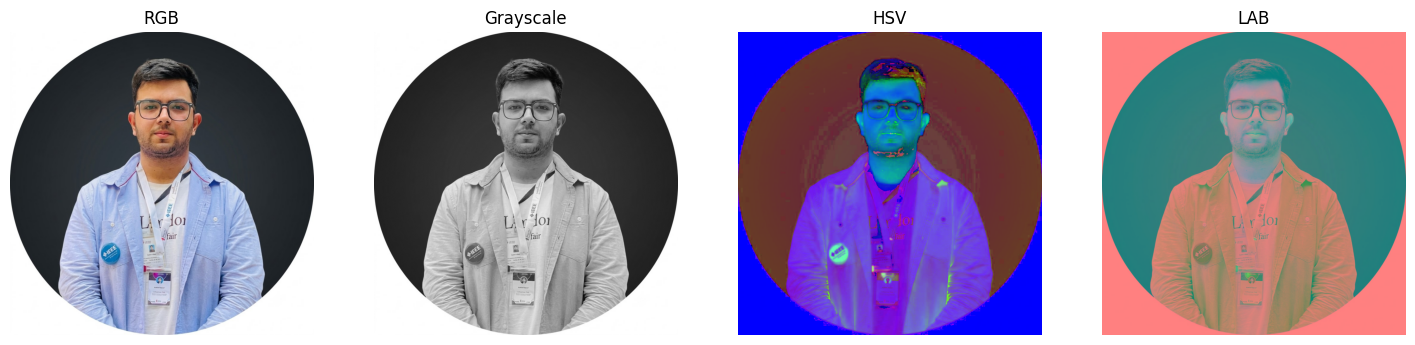

In [ ]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

fig, axs = plt.subplots(1, 4, figsize=(18, 5))
axs[0].imshow(rgb); axs[0].set_title("RGB"); axs[0].axis("off")
axs[1].imshow(gray, cmap="gray"); axs[1].set_title("Grayscale"); axs[1].axis("off")
axs[2].imshow(hsv); axs[2].set_title("HSV"); axs[2].axis("off")
axs[3].imshow(lab); axs[3].set_title("LAB"); axs[3].axis("off")
plt.show()

### Explanation

This experiment converts the same image into four different color spaces: **RGB**, **Grayscale**, **HSV**, and **LAB**.

- **RGB** is the standard display format (Red/Green/Blue channels).
- **Grayscale** collapses color into a single brightness channel, simplifying processing for tasks like edge detection or thresholding.
- **HSV** (Hue, Saturation, Value) separates *color identity* from *brightness*, making it much easier to isolate a specific color regardless of lighting conditions.
- **LAB** separates lightness (L) from color (A/B channels), which is useful for lighting-invariant color comparison.

Understanding color spaces is fundamental because a computer never "sees" a picture the way we do — it only sees numbers arranged according to a chosen color model, and the right model can make a task dramatically easier.


---
## Experiment 2: Image Filtering



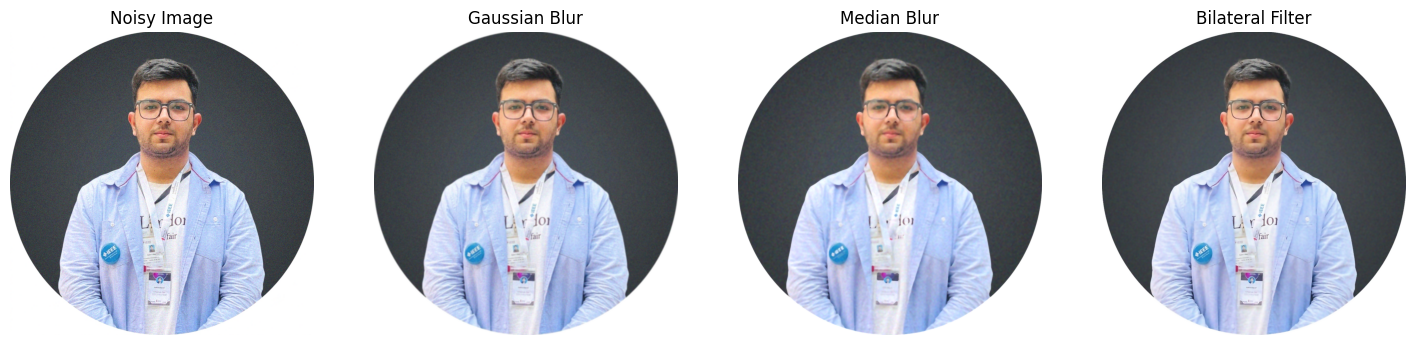

In [ ]:
noisy = image.copy()
noise = np.random.randint(0, 50, image.shape, dtype='uint8')
noisy = cv2.add(image, noise)

gaussian = cv2.GaussianBlur(noisy, (7, 7), 0)
median = cv2.medianBlur(noisy, 7)
bilateral = cv2.bilateralFilter(noisy, 9, 75, 75)

fig, axs = plt.subplots(1, 4, figsize=(18, 5))
axs[0].imshow(cv2.cvtColor(noisy, cv2.COLOR_BGR2RGB)); axs[0].set_title("Noisy Image"); axs[0].axis("off")
axs[1].imshow(cv2.cvtColor(gaussian, cv2.COLOR_BGR2RGB)); axs[1].set_title("Gaussian Blur"); axs[1].axis("off")
axs[2].imshow(cv2.cvtColor(median, cv2.COLOR_BGR2RGB)); axs[2].set_title("Median Blur"); axs[2].axis("off")
axs[3].imshow(cv2.cvtColor(bilateral, cv2.COLOR_BGR2RGB)); axs[3].set_title("Bilateral Filter"); axs[3].axis("off")
plt.show()

### Explanation

This experiment artificially adds random noise to the image, then removes it using three different filtering techniques: **Gaussian Blur**, **Median Blur**, and **Bilateral Filter**.

- **Gaussian Blur** averages nearby pixels using a bell-curve weighting. It produces a smooth result but blurs edges along with the noise.
- **Median Blur** replaces each pixel with the median value of its neighborhood. It is excellent at removing "salt-and-pepper" style noise while preserving edges better than Gaussian blur.
- **Bilateral Filter** smooths flat regions while *preserving* edges, by only averaging pixels that are both spatially close *and* similar in color. It is the most "intelligent" of the three, at the cost of being slower.

Real-world images are rarely clean — sensor noise, compression artifacts, or poor lighting all introduce noise — so choosing the right filter is an important preprocessing decision.


---
## Experiment 3: Edge Detection



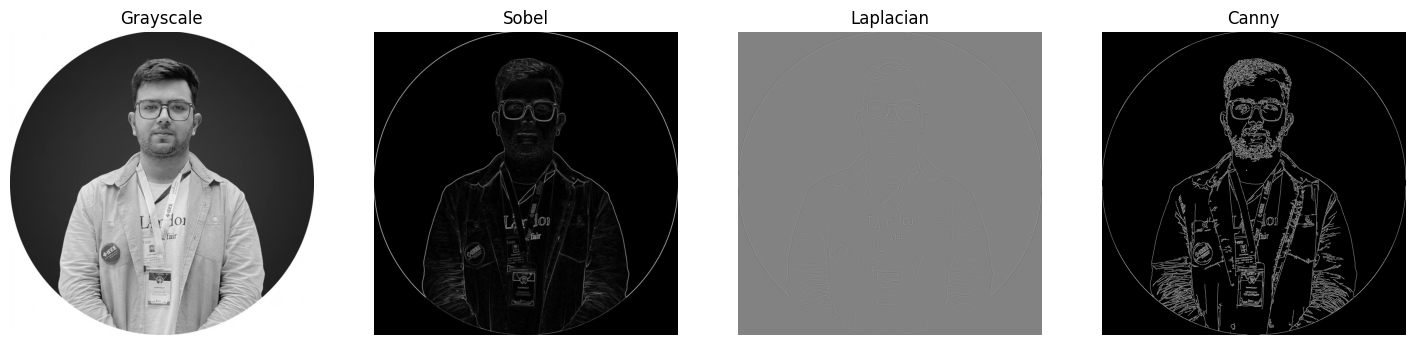

In [ ]:
gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

sobelx = cv2.Sobel(gray_img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray_img, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobelx, sobely)

laplacian = cv2.Laplacian(gray_img, cv2.CV_64F)

canny = cv2.Canny(gray_img, 50, 150)

fig, axs = plt.subplots(1, 4, figsize=(18, 5))
axs[0].imshow(gray_img, cmap="gray"); axs[0].set_title("Grayscale"); axs[0].axis("off")
axs[1].imshow(sobel_combined, cmap="gray"); axs[1].set_title("Sobel"); axs[1].axis("off")
axs[2].imshow(laplacian, cmap="gray"); axs[2].set_title("Laplacian"); axs[2].axis("off")
axs[3].imshow(canny, cmap="gray"); axs[3].set_title("Canny"); axs[3].axis("off")
plt.show()

### Explanation

This experiment runs three classic edge-detection operators on the grayscale image: **Sobel**, **Laplacian**, and **Canny**.

- **Sobel** computes intensity gradients separately in the x and y direction, then combines them (`cv2.magnitude`) to highlight edges with directional sensitivity.
- **Laplacian** is a second-derivative operator that highlights regions of rapid intensity change in all directions at once; it is more sensitive to noise than Sobel.
- **Canny** is a multi-stage algorithm (noise reduction → gradient calculation → non-max suppression → hysteresis thresholding) that produces the cleanest, thinnest edges of the three. This is why it is the industry-standard choice for most real-world edge detection tasks.

Edges (sharp intensity changes) are one of the most fundamental features in Computer Vision, since they often outline object boundaries.


---
## Experiment 4: Contour Detection


Number of contours detected: 1


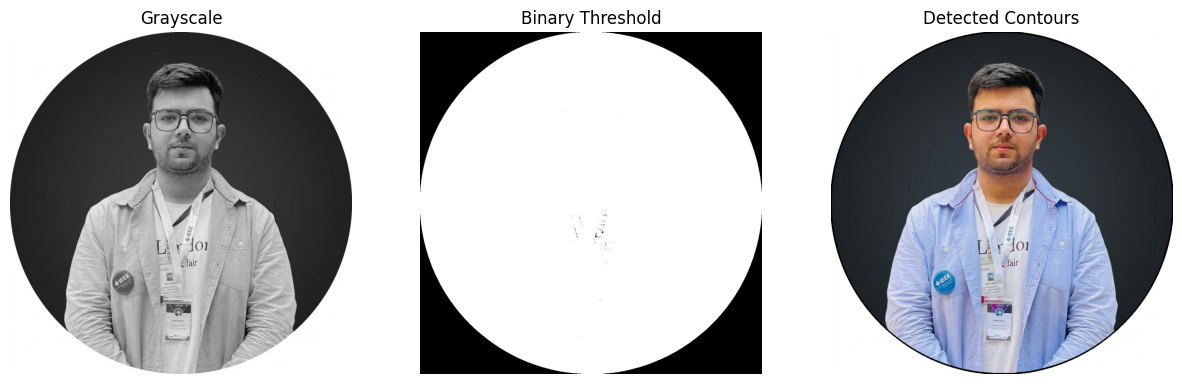

In [ ]:
gray_c = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray_c, 240, 255, cv2.THRESH_BINARY_INV)

contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(f"Number of contours detected: {len(contours)}")

contour_img = image.copy()
cv2.drawContours(contour_img, contours, -1, (0, 0, 0), 3)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(gray_c, cmap="gray"); axs[0].set_title("Grayscale"); axs[0].axis("off")
axs[1].imshow(thresh, cmap="gray"); axs[1].set_title("Binary Threshold"); axs[1].axis("off")
axs[2].imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB)); axs[2].set_title("Detected Contours"); axs[2].axis("off")
plt.show()

### Explanation

This experiment thresholds the grayscale image into pure black-and-white (`cv2.threshold` with `THRESH_BINARY_INV`), then uses `cv2.findContours` to detect the outlines of connected white regions, and draws them onto the original image.

While edge detection finds *pixels* that look like boundaries, contour detection finds *closed shapes* — continuous curves outlining a connected region. This is the necessary step before we can measure, count, or classify objects, since a contour is a structured object (a list of points) rather than just a scattered set of edge pixels.


---
## Experiment 5: Shape Detection


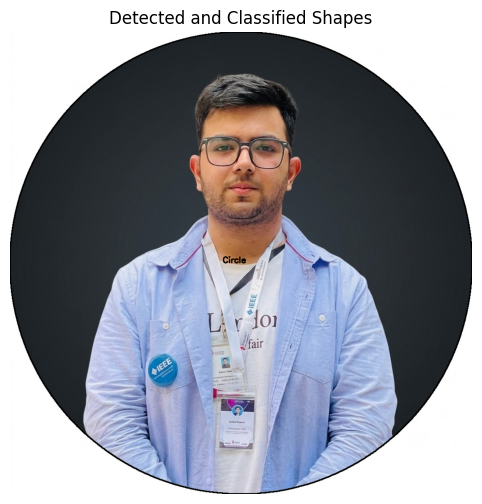

In [ ]:
def detect_shape(contour):
    perimeter = cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, 0.04 * perimeter, True)
    vertices = len(approx)

    if vertices == 3:
        return "Triangle"
    elif vertices == 4:
        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = w / float(h)
        return "Square" if 0.95 <= aspect_ratio <= 1.05 else "Rectangle"
    elif vertices == 5:
        return "Pentagon"
    else:
        area = cv2.contourArea(contour)
        circularity = 4 * np.pi * (area / (perimeter ** 2)) if perimeter > 0 else 0
        return "Circle" if circularity > 0.8 else f"{vertices}-sided Polygon"

output = image.copy()

for contour in contours:
    shape_name = detect_shape(contour)

    M = cv2.moments(contour)
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
    else:
        cx, cy = 0, 0

    cv2.drawContours(output, [contour], -1, (0, 0, 0), 2)
    cv2.putText(output, shape_name, (cx - 40, cy),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Detected and Classified Shapes")
plt.axis("off")
plt.show()

### Explanation

This experiment builds on the contours found in Experiment 4 by classifying each one geometrically:

1. `cv2.approxPolyDP` simplifies each contour into an approximate polygon with fewer points.
2. The number of vertices determines the shape: 3 → Triangle, 4 → Square/Rectangle (distinguished by aspect ratio), 5 → Pentagon.
3. For anything else, **circularity** is calculated (`4π × Area / Perimeter²`) — a value near 1.0 means the shape is close to a perfect circle.
4. `cv2.moments` finds each contour's centroid (center point), used to place the shape's label directly on top of it.

This is a good example of classical (non-deep-learning) shape classification using pure geometry instead of a trained model. It is fast and interpretable, and works well for controlled scenes (e.g., detecting shapes on a whiteboard or in an industrial inspection setup), but does not generalize the way a trained CNN would to messy real-world scenes.
